# Импорты и генерация синтетических данных

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Функция генерации синтетических данных
def generate_synthetic_data(num_points_per_wall=200, noise_std=0.05, room_size=5.0):
    walls = []
    # Низ
    x = np.linspace(-room_size, room_size, num_points_per_wall)
    walls.append(np.column_stack((x, np.full_like(x, -room_size))))
    # Верх
    walls.append(np.column_stack((x, np.full_like(x, room_size))))
    # Лево
    y = np.linspace(-room_size, room_size, num_points_per_wall)
    walls.append(np.column_stack((np.full_like(y, -room_size), y)))
    # Право
    walls.append(np.column_stack((np.full_like(y, room_size), y)))

    points = np.vstack(walls)
    # Добавляем шум
    points += np.random.normal(0, noise_std, points.shape)
    return points

points = generate_synthetic_data()
print(f"Сгенерировано точек: {len(points)}")

Сгенерировано точек: 800


**Функция перевода координат из полярных координат**

In [2]:
def polar_to_cartesian(ranges, angles):
    """
    Переводит полярные координаты (range, angle) в декартовы (x, y)
    ranges: массив расстояний
    angles: массив углов в радианах
    """
    x = ranges * np.cos(angles)
    y = ranges * np.sin(angles)
    return np.column_stack((x, y))

**Создание аккумулятора Хафа**

In [3]:
def hough_transform(points, theta_res=1.0, rho_res=0.05):
    thetas = np.deg2rad(np.arange(-90, 90, theta_res))
    n_theta = len(thetas)

    # Максимальное значение rho
    max_rho = np.max(np.sqrt(points[:,0]**2 + points[:,1]**2)) * 1.2
    rhos = np.arange(-max_rho, max_rho, rho_res)
    n_rho = len(rhos)

    accumulator = np.zeros((n_rho, n_theta), dtype=np.int32)

    cos_t = np.cos(thetas)
    sin_t = np.sin(thetas)

    for x, y in points:
        for t_idx in range(n_theta):
            rho = x * cos_t[t_idx] + y * sin_t[t_idx]
            rho_idx = int(round((rho + max_rho) / rho_res))
            if 0 <= rho_idx < n_rho:
                accumulator[rho_idx, t_idx] += 1

    return accumulator, rhos, thetas

accumulator, rhos, thetas = hough_transform(points, theta_res=1.0, rho_res=0.05)
print(f"Размер аккумулятора: {accumulator.shape}")

Размер аккумулятора: (343, 180)


**Поиск пиков в аккумуляторе**

In [19]:
def find_hough_peaks(accumulator, rhos, thetas, threshold_ratio=0.7):
    threshold = np.max(accumulator) * threshold_ratio
    peaks = []

    # Находим все точки выше порога
    rho_idx, theta_idx = np.where(accumulator > threshold)

    for ri, ti in zip(rho_idx, theta_idx):
        rho = rhos[ri]
        theta = thetas[ti]
        votes = accumulator[ri, ti]
        peaks.append((rho, theta, votes))

    peaks.sort(key=lambda x: x[2], reverse=True)

    # Убираем дубликаты
    selected_peaks = []
    for peak in peaks:
        if not selected_peaks:
            selected_peaks.append(peak)
            continue
        # Проверяем близость
        is_close = False
        for sp in selected_peaks:
            if abs(peak[0] - sp[0]) < 0.4 and abs(np.rad2deg(peak[1] - sp[1])) < 10:
                is_close = True
                break
        if not is_close:
            selected_peaks.append(peak)

    return selected_peaks

peaks = find_hough_peaks(accumulator, rhos, thetas)
print(f"Найдено линий: {len(peaks)}")
for i, (rho, theta, votes) in enumerate(peaks[:6]):
    print(f"Линия {i+1}: rho = {rho:.2f}, theta = {np.rad2deg(theta):.1f}°, votes = {votes}")

Найдено линий: 4
Линия 1: rho = 5.03, theta = -90.0°, votes = 83
Линия 2: rho = -5.02, theta = -90.0°, votes = 78
Линия 3: rho = -4.97, theta = 0.0°, votes = 75
Линия 4: rho = 5.03, theta = 0.0°, votes = 72


**Результат — отрисовка найденных линий стен поверх точек лидара**

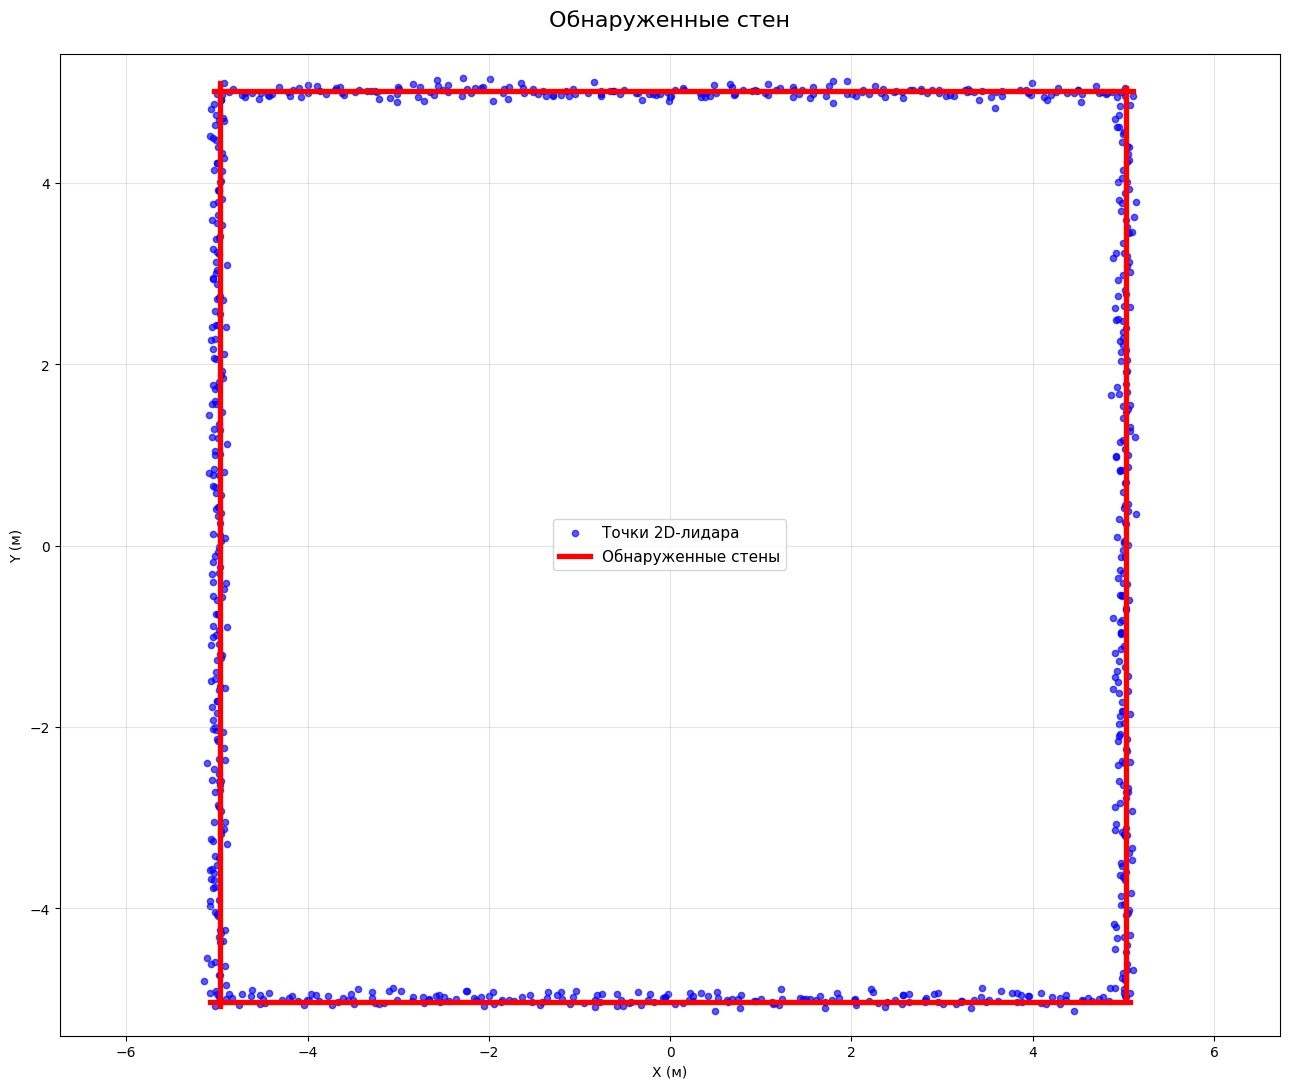

In [24]:
def plot_walls_finite(points, peaks, dist_threshold=0.15):

    plt.figure(figsize=(13, 11))
    plt.scatter(points[:, 0], points[:, 1], s=20, c='blue', alpha=0.65,
                label='Точки 2D-лидара')

    colors = ['red']

    for i, (rho, theta, votes) in enumerate(peaks):
        color = colors[i % len(colors)]
        cos_t = np.cos(theta)
        sin_t = np.sin(theta)
        normal = np.array([cos_t, sin_t])
        direction = np.array([-sin_t, cos_t])   # направление вдоль стены

        # Находим точки, близкие к линии
        distances = np.abs(points @ normal - rho)
        close_mask = distances < dist_threshold
        close_points = points[close_mask]

        if len(close_points) < 10:
            continue

        # Базовая точка на линии
        p0 = rho * normal

        # Проекция точек на направление стены
        vec = close_points - p0
        t_params = vec @ direction

        t_min = t_params.min()
        t_max = t_params.max()

        p1 = p0 + t_min * direction
        p2 = p0 + t_max * direction

        # Рисуем стену
        plt.plot([p1[0], p2[0]], [p1[1], p2[1]],
                 color=color, linewidth=3.8, alpha=1,
                 label='Обнаруженные стены' if i == 0 else "")

    plt.axis('equal')
    plt.grid(True, alpha=0.35)
    plt.title('Обнаруженные стен',
              fontsize=16, pad=20)
    plt.xlabel('X (м)')
    plt.ylabel('Y (м)')
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

plot_walls_finite(points, peaks, dist_threshold=0.15)